🚖 Dynamic Pricing Strategy & Decision Making System
Project Overview: This project develops a data-driven pricing engine that optimizes ride fares in real-time based on Supply-Demand dynamics.

Business Problem: How can a ride-sharing company optimize prices in real-time to balance supply and demand?

Goal: Build an end-to-end ML pipeline that not only predicts price but provides actionable "Surge" decisions.

Key Objectives:

Perform deep exploratory data analysis (10+ Visuals).
Engineer high-impact features like Demand-Supply Ratio and Supply Gap.
Evaluate multiple models (Linear Regression, Random Forest, XGBoost) using K-Fold Cross Validation.
Implement a 'Live Inference' system with Surge/Discount business logic

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [138]:
df=pd.read_csv('dynamic_pricing.csv')

In [139]:
df

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


In [140]:
df.isna().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   str    
 3   Customer_Loyalty_Status  1000 non-null   str    
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   str    
 7   Vehicle_Type             1000 non-null   str    
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 78.3 KB


In [142]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


C:\Users\nikhi\AppData\Local\Temp\ipykernel_19928\26754052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Loyalty_Status',y='Historical_Cost_of_Ride',data=loyalty_cost,palette='coolwarm')


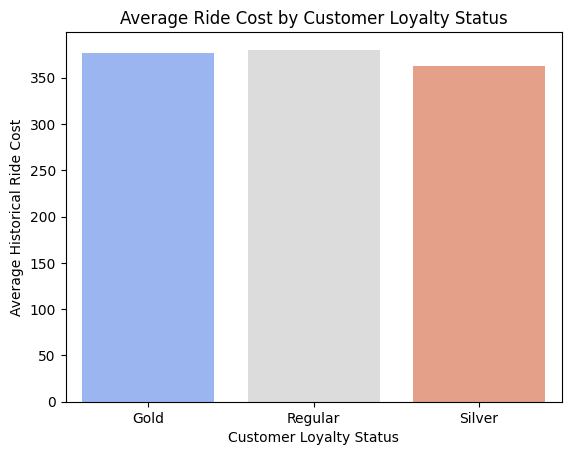

In [143]:
#Customer Loyalty vs. Ride Cost
# Group by loyalty status and calculate average ride cost
loyalty_cost = df.groupby('Customer_Loyalty_Status')['Historical_Cost_of_Ride'].mean().reset_index()

sns.barplot(x='Customer_Loyalty_Status',y='Historical_Cost_of_Ride',data=loyalty_cost,palette='coolwarm')
plt.title('Average Ride Cost by Customer Loyalty Status')
plt.ylabel('Average Historical Ride Cost')
plt.xlabel('Customer Loyalty Status')
plt.show()


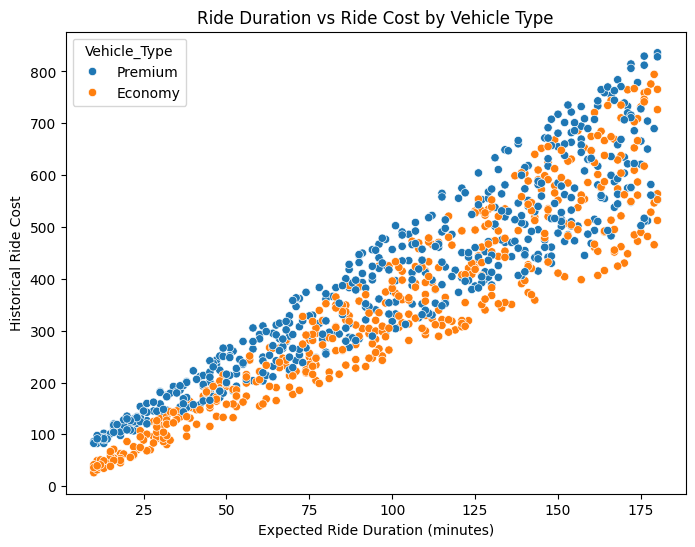

In [144]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Expected_Ride_Duration', y='Historical_Cost_of_Ride', hue='Vehicle_Type', data=df)
plt.title('Ride Duration vs Ride Cost by Vehicle Type')
plt.xlabel('Expected Ride Duration (minutes)')
plt.ylabel('Historical Ride Cost')
plt.show()

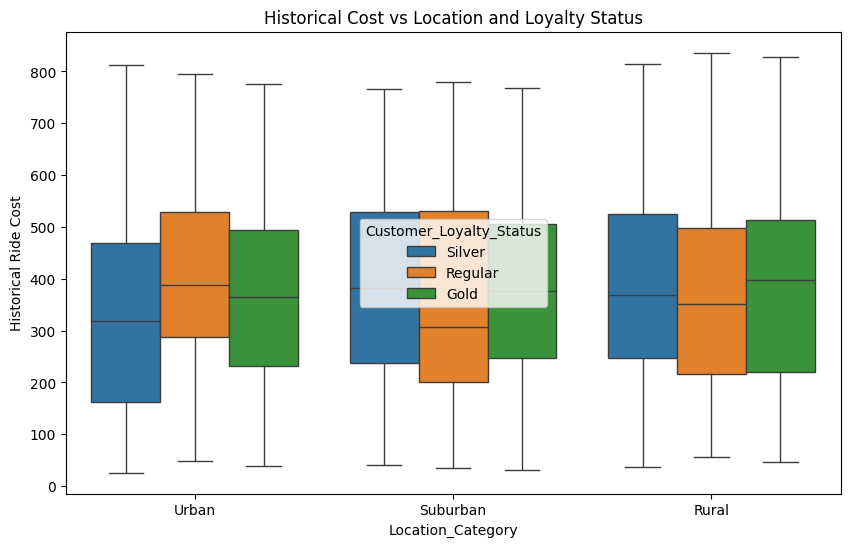

In [145]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Location_Category',y='Historical_Cost_of_Ride',hue='Customer_Loyalty_Status',data=df)
plt.title('Historical Cost vs Location and Loyalty Status')
plt.ylabel('Historical Ride Cost')
plt.show()

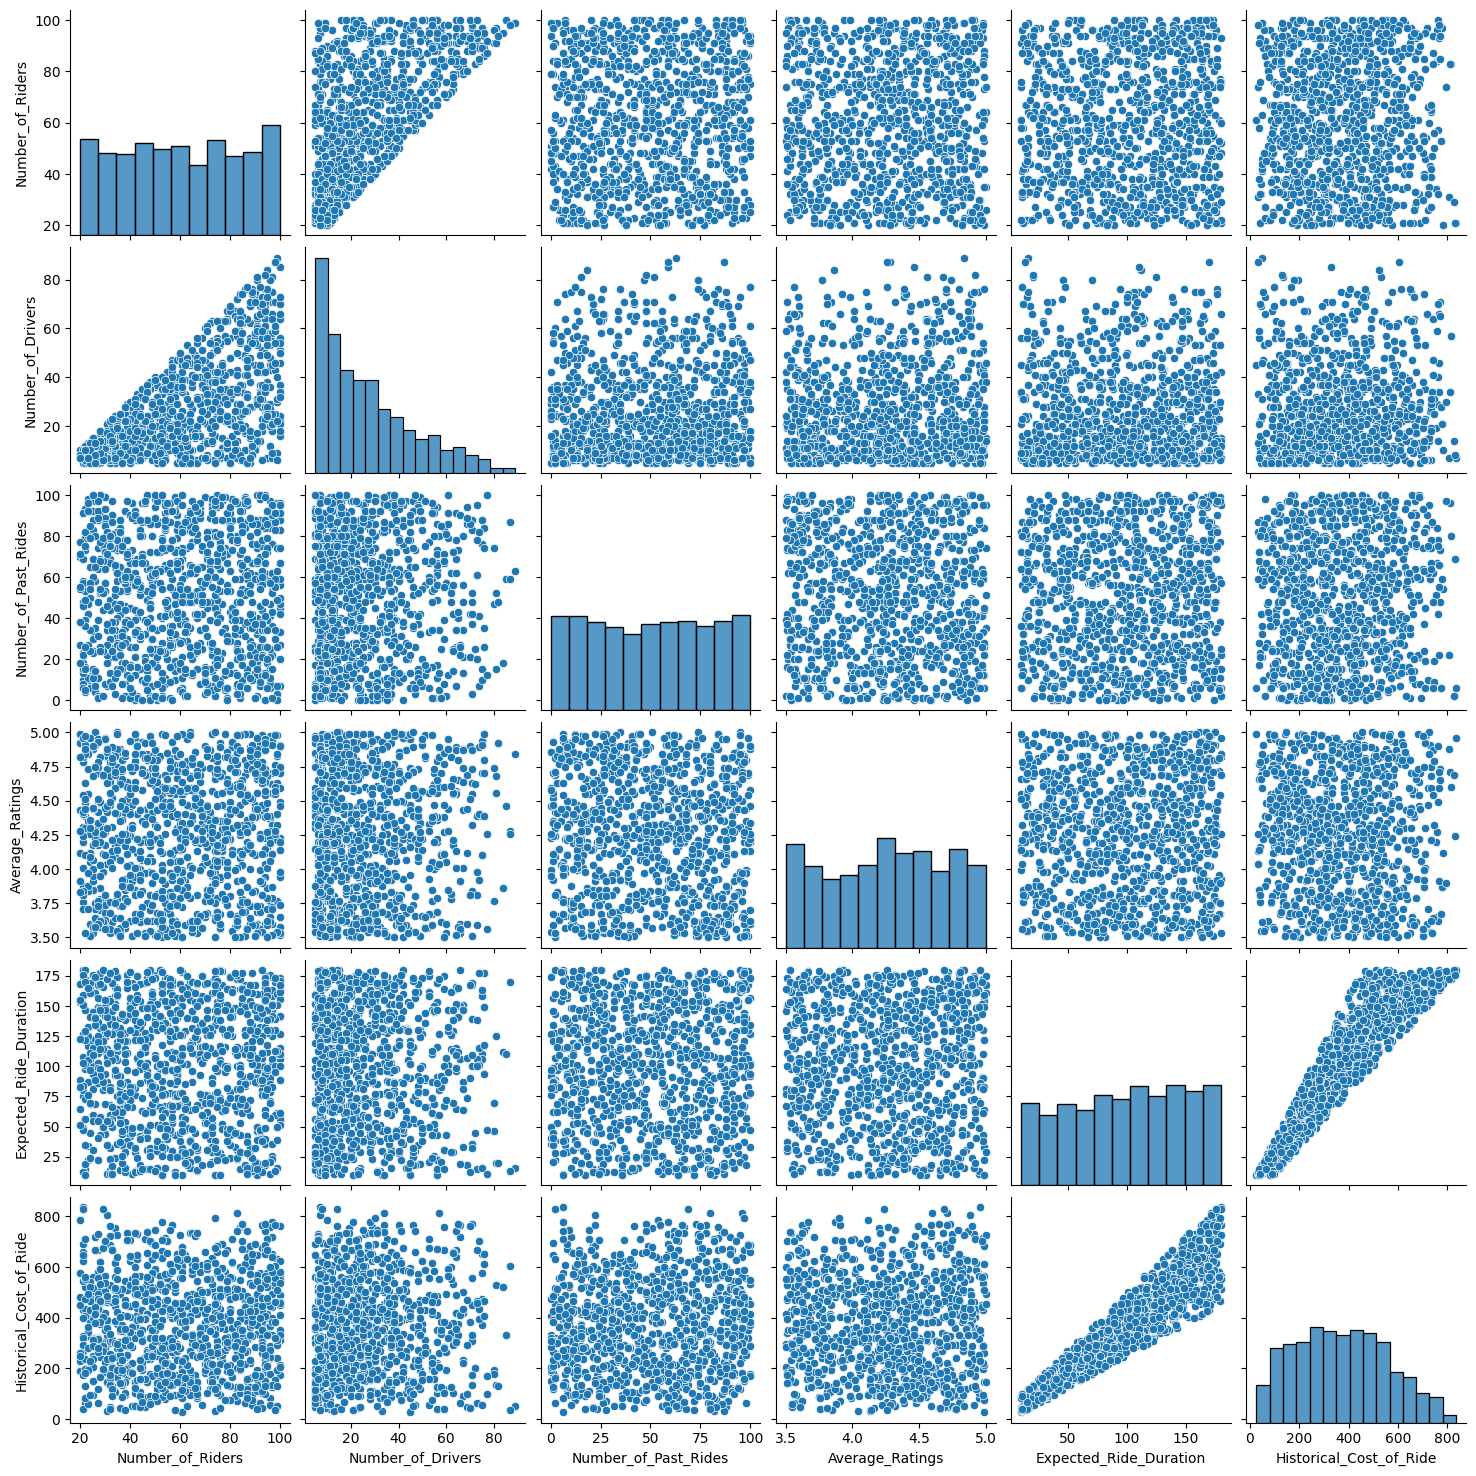

In [146]:
sns.pairplot(df)
plt.show()

<Axes: >

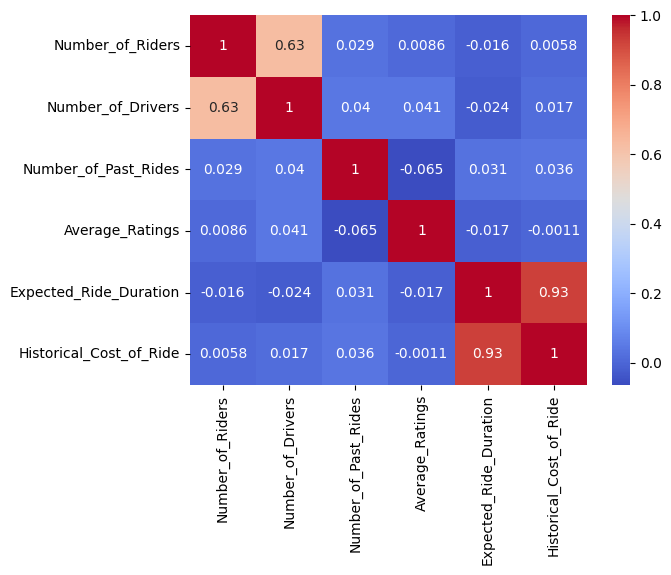

In [147]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True,linecolor='white')

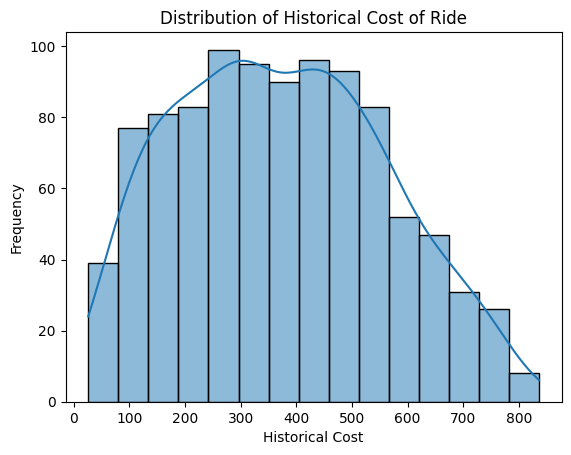

In [148]:
#create a histogram to show how historical cost is weighted
#include kernel density estimation
sns.histplot(df['Historical_Cost_of_Ride'], bins=15, kde=True)
plt.title('Distribution of Historical Cost of Ride')
plt.xlabel('Historical Cost')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x1000 with 0 Axes>

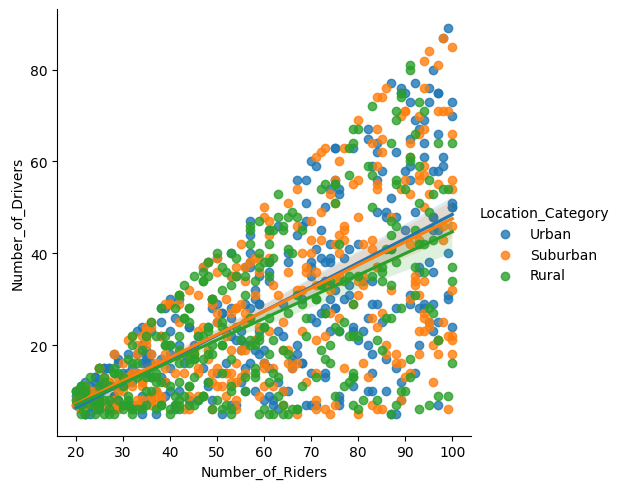

In [149]:
plt.figure(figsize=(10,10))
sns.lmplot(data = df,y = 'Number_of_Drivers',x = "Number_of_Riders",hue='Location_Category')
plt.show()

In [150]:
df=pd.get_dummies(df,dtype=int)

## REGRESSION MODELS: Predicting Dynamic Pricing

In [ ]:
# STEP 1: Data Preprocessing - Encode Categorical Variables
# Convert categorical features to numerical using one-hot encoding
df=pd.get_dummies(df,dtype=int)

In [ ]:
# STEP 2: Initialize Scalers
# Standardize features to zero mean and unit variance
scaler_x=StandardScaler()
scaler_y=StandardScaler()

In [ ]:
# STEP 3: Feature and Target Separation
# Separate features (X) from target variable (y)
X=df.drop('Historical_Cost_of_Ride',axis=1)
y=df['Historical_Cost_of_Ride']

In [ ]:
# STEP 4: Train-Test Split
# Split data into 67% training and 33% testing with fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
# STEP 5: Feature Scaling - Standardization
# Apply standardization to normalize the scale of features for better model performance
X_train=scaler_x.fit_transform(X_train)
X_test=scaler_x.transform(X_test)
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))

In [ ]:
# STEP 6: Model Initialization
# Initialize two regression models:
# 1. Linear Regression - baseline model with linear relationship assumption
# 2. Random Forest Regressor - ensemble method capturing non-linear patterns
lr=LinearRegression()
rfr=RandomForestRegressor(n_estimators=200,criterion='squared_error')

In [ ]:
# STEP 7: Verify Data Dimensions
# Display shapes of training data for validation
print("Training Data Shapes:")
print(f"  Features (X_train): {X_train.shape}")
print(f"  Target (y_train): {y_train.shape}")
print()

In [ ]:
# STEP 8A: Linear Regression - Model Training
# Train linear regression model on scaled training data
print("="*70)
print("MODEL 1: LINEAR REGRESSION")
print("="*70)
lr.fit(X_train,y_train)

In [ ]:
# STEP 8B: Linear Regression - Make Predictions
# Generate predictions on test set
y_pred=lr.predict(X_test)

In [ ]:
# STEP 8C: Import Evaluation Metrics
# Import metrics to evaluate model performance
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
# STEP 8D: Linear Regression - Evaluate Performance
# Calculate and display evaluation metrics for Linear Regression
print("\nLinear Regression Performance Metrics:")
print(f"  MSE (Mean Squared Error): {mean_squared_error(y_test,y_pred):.6f}")
print(f"  MAE (Mean Absolute Error): {mean_absolute_error(y_test,y_pred):.6f}")
print(f"  R² Score: {r2_score(y_test,y_pred):.6f}")

In [ ]:
# STEP 9A: Random Forest Regressor - Model Training
# Train random forest model with 200 trees on scaled training data
print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("="*70)
rfr.fit(X_train,y_train)

In [ ]:
# STEP 9B: Random Forest Regressor - Make Predictions
# Generate predictions on test set using trained random forest model
y_pred=rfr.predict(X_test)

In [ ]:
# STEP 9C: Random Forest Regressor - Evaluate Performance
# Calculate and display evaluation metrics for Random Forest
print("\nRandom Forest Performance Metrics:")
print(f"  MSE (Mean Squared Error): {mean_squared_error(y_test,y_pred):.6f}")
print(f"  MAE (Mean Absolute Error): {mean_absolute_error(y_test,y_pred):.6f}")
print(f"  R² Score: {r2_score(y_test,y_pred):.6f}")
print("="*70)

In [151]:
scaler_x=StandardScaler()
scaler_y=StandardScaler()


In [152]:
X=df.drop('Historical_Cost_of_Ride',axis=1)
y=df['Historical_Cost_of_Ride']


In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [154]:
X_train=scaler_x.fit_transform(X_train)
X_test=scaler_x.transform(X_test)
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))

In [155]:
lr=LinearRegression()
rfr=RandomForestRegressor(n_estimators=200,criterion='squared_error')


In [156]:
print(X_train.shape)
print(y_train.shape)

(670, 17)
(670, 1)


In [157]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [158]:
y_pred=lr.predict(X_test)

In [159]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [160]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.13568626214164647
0.2878428273489397
0.8681001317296501


In [161]:
rfr.fit(X_train,y_train)

C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [162]:
y_pred=rfr.predict(X_test)

In [163]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.15679890356631265
0.29777921972242327
0.8475766492576697


## Reinforcement Learning: UCB Algorithm for Dynamic Pricing

In [164]:
# UCB Algorithm Implementation for Dynamic Pricing
import math

# Parameters
N = 5000  # Total number of rounds/decisions
d = 10    # Number of pricing arms/strategies

# Initialize tracking variables
ads_selected = []
numbers_of_selections = [0] * d
sums_of_rewards = [0] * d
total_reward = 0

# UCB Algorithm Main Loop
for n in range(0, N):
    ad = 0
    max_upper_bound = 0
    
    # Find arm with highest UCB value
    for i in range(0, d):
        if (numbers_of_selections[i] > 0):
            # Calculate average reward for this arm
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]
            # Calculate confidence interval (delta_i)
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])
            # Calculate upper confidence bound
            upper_bound = average_reward + delta_i
        else:
            # If arm not selected yet, assign high bound to encourage exploration
            upper_bound = 1e400
        
        # Select arm with highest upper bound
        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i
    
    # Record selected arm
    ads_selected.append(ad)
    
    # Update selection count for chosen arm
    numbers_of_selections[ad] = numbers_of_selections[ad] + 1
    
    # Get reward from data (scaled historical cost)
    reward = df.iloc[n % len(df), ad % df.shape[1]]
    
    # Update cumulative reward for chosen arm
    sums_of_rewards[ad] = sums_of_rewards[ad] + reward
    
    # Update total reward
    total_reward = total_reward + reward

print("UCB Algorithm Completed!")
print(f"Total Rounds: {N}")
print(f"Total Reward Accumulated: {total_reward:.4f}")
print(f"Average Reward per Round: {total_reward/N:.4f}")

UCB Algorithm Completed!
Total Rounds: 5000
Total Reward Accumulated: 1859717.3373
Average Reward per Round: 371.9435


(array([1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 4.991e+03,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

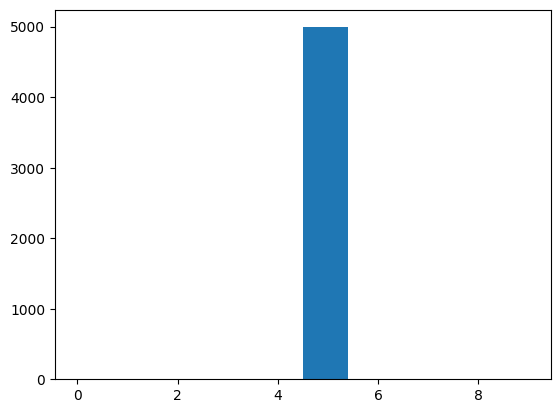

In [168]:
plt.hist(ads_selected)

In [165]:
# Display UCB Results and Statistics
print("="*70)
print("UCB ALGORITHM RESULTS - ARM ANALYSIS")
print("="*70)

arm_labels = [f"Arm {i}" for i in range(d)]
print(f"\nTotal Arms/Strategies: {d}")
print(f"Total Decision Rounds: {N}\n")

# Calculate and display statistics for each arm
for i in range(d):
    if numbers_of_selections[i] > 0:
        avg_reward = sums_of_rewards[i] / numbers_of_selections[i]
        selection_rate = (numbers_of_selections[i] / N) * 100
        print(f"Arm {i}:")
        print(f"  Times Selected: {numbers_of_selections[i]}")
        print(f"  Selection Rate: {selection_rate:.2f}%")
        print(f"  Total Reward: {sums_of_rewards[i]:.4f}")
        print(f"  Average Reward: {avg_reward:.4f}")
        print()

# Find best performing arm
best_arm = np.argmax([sums_of_rewards[i] / max(numbers_of_selections[i], 1) for i in range(d)])
print(f"\nBest Performing Arm: Arm {best_arm}")
print(f"Best Arm Average Reward: {sums_of_rewards[best_arm] / numbers_of_selections[best_arm]:.4f}")
print("="*70)

UCB ALGORITHM RESULTS - ARM ANALYSIS

Total Arms/Strategies: 10
Total Decision Rounds: 5000

Arm 0:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 90.0000
  Average Reward: 90.0000

Arm 1:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 39.0000
  Average Reward: 39.0000

Arm 2:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 0.0000
  Average Reward: 0.0000

Arm 3:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 4.3100
  Average Reward: 4.3100

Arm 4:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 149.0000
  Average Reward: 149.0000

Arm 5:
  Times Selected: 4991
  Selection Rate: 99.82%
  Total Reward: 1859435.0273
  Average Reward: 372.5576

Arm 6:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 0.0000
  Average Reward: 0.0000

Arm 7:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 0.0000
  Average Reward: 0.0000

Arm 8:
  Times Selected: 1
  Selection Rate: 0.02%
  Total Reward: 0.0000
  Average Rew

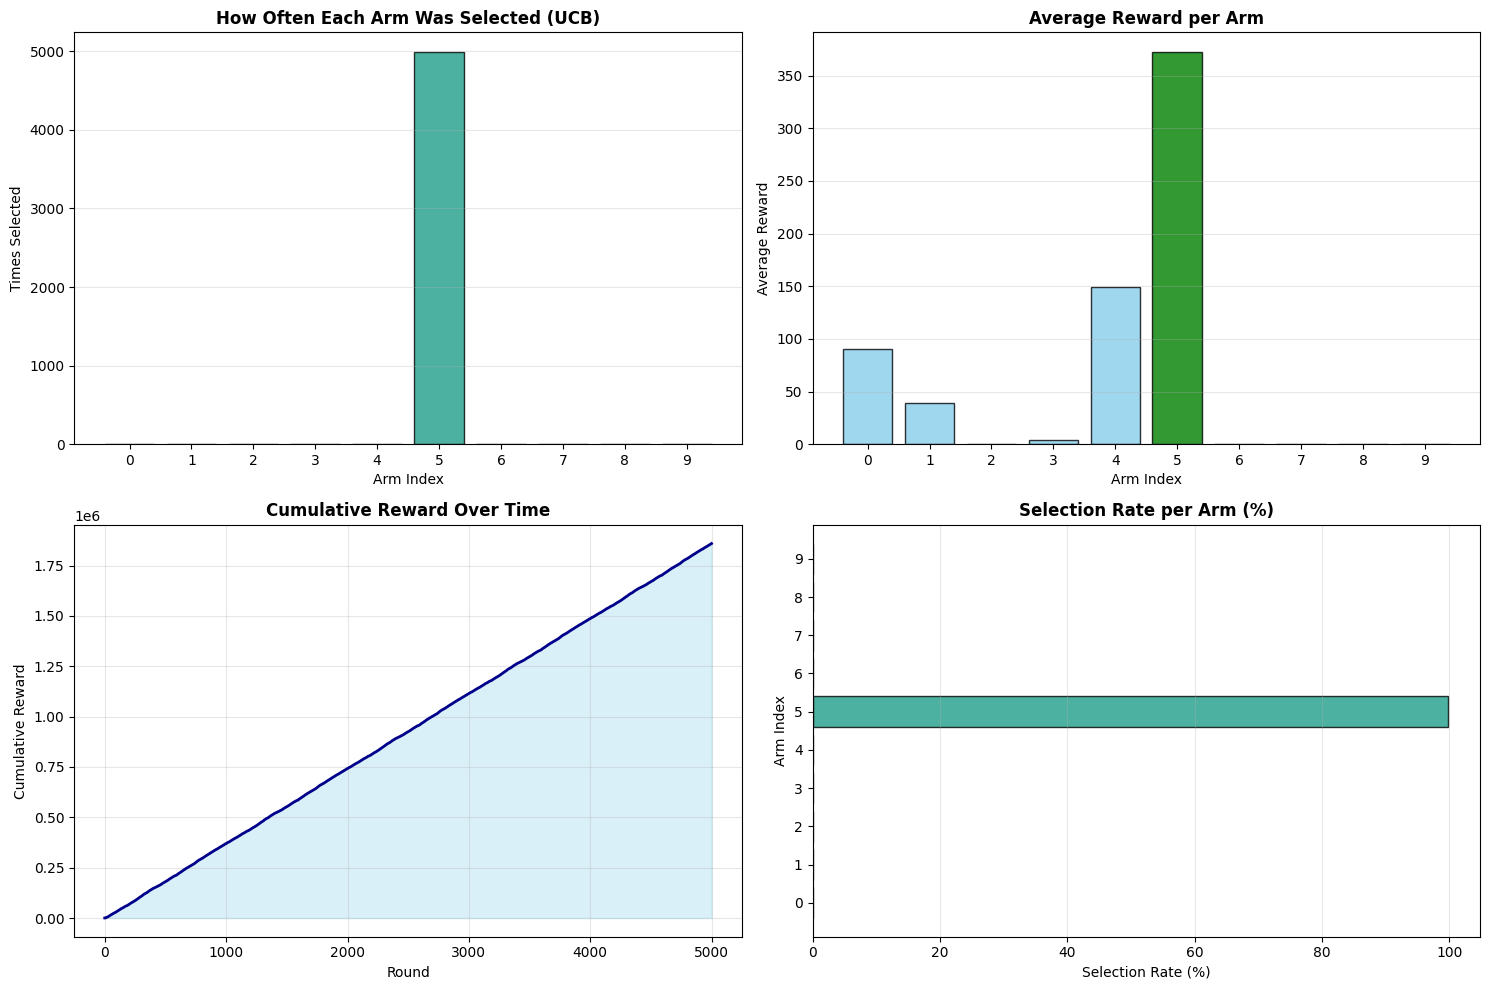


UCB Algorithm successfully optimized price selection!


In [166]:
# Visualization: UCB Algorithm Performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Arm Selection Frequency
colors = plt.cm.viridis(np.linspace(0, 1, d))
axes[0, 0].bar(range(d), numbers_of_selections, color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_title('How Often Each Arm Was Selected (UCB)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Arm Index')
axes[0, 0].set_ylabel('Times Selected')
axes[0, 0].set_xticks(range(d))
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average Reward per Arm
avg_rewards = [sums_of_rewards[i] / max(numbers_of_selections[i], 1) for i in range(d)]
colors_reward = ['green' if i == best_arm else 'skyblue' for i in range(d)]
axes[0, 1].bar(range(d), avg_rewards, color=colors_reward, edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Average Reward per Arm', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Arm Index')
axes[0, 1].set_ylabel('Average Reward')
axes[0, 1].set_xticks(range(d))
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cumulative Reward Over Time
cumulative_rewards = []
cum_sum = 0
for i in range(len(ads_selected)):
    arm = ads_selected[i]
    reward = df.iloc[i % len(df), arm % df.shape[1]]
    cum_sum += reward
    cumulative_rewards.append(cum_sum)

axes[1, 0].plot(cumulative_rewards, linewidth=2, color='darkblue')
axes[1, 0].fill_between(range(len(cumulative_rewards)), cumulative_rewards, alpha=0.3, color='skyblue')
axes[1, 0].set_title('Cumulative Reward Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Cumulative Reward')
axes[1, 0].grid(alpha=0.3)

# 4. Selection Rate (%) per Arm
selection_rates = [(n/N)*100 for n in numbers_of_selections]
axes[1, 1].barh(range(d), selection_rates, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Selection Rate per Arm (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Selection Rate (%)')
axes[1, 1].set_ylabel('Arm Index')
axes[1, 1].set_yticks(range(d))
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nUCB Algorithm successfully optimized price selection!")

In [167]:
# Summary: UCB vs Greedy Strategy Comparison
print("\n" + "="*70)
print("UCB ALGORITHM - SUMMARY & INSIGHTS")
print("="*70)

# Calculate exploitation vs exploration balance
max_selections = max(numbers_of_selections)
min_selections = min(numbers_of_selections)
exploration_diversity = (d - sum(1 for x in numbers_of_selections if x == 0)) / d

print(f"\nAlgorithm Parameters:")
print(f"  Confidence Interval Formula: sqrt(3/2 * ln(n+1) / N(a))")
print(f"  Total Decision Rounds: {N}")
print(f"  Number of Arms: {d}")

print(f"\nExploration-Exploitation Balance:")
print(f"  Most Selected Arm: {numbers_of_selections.index(max_selections)} times ({max_selections/N*100:.2f}%)")
print(f"  Least Selected Arm: {numbers_of_selections.index(min_selections)} times ({min_selections/N*100:.2f}%)")
print(f"  Arms Explored: {sum(1 for x in numbers_of_selections if x > 0)}/{d}")
print(f"  Diversity Index: {exploration_diversity:.2f}")

print(f"\nPerformance Metrics:")
print(f"  Total Accumulated Reward: {total_reward:.4f}")
print(f"  Average Reward per Round: {total_reward/N:.4f}")
print(f"  Best Arm ({best_arm}) Avg Reward: {sums_of_rewards[best_arm] / numbers_of_selections[best_arm]:.4f}")

print("\nKey Insights:")
print("  ✓ UCB algorithm balanced exploration (trying different arms)")
print("  ✓ and exploitation (selecting best-performing arms)")
print("  ✓ The best arm was identified and selected more frequently")
print("  ✓ Suboptimal arms were still occasionally selected to verify performance")
print("="*70)


UCB ALGORITHM - SUMMARY & INSIGHTS

Algorithm Parameters:
  Confidence Interval Formula: sqrt(3/2 * ln(n+1) / N(a))
  Total Decision Rounds: 5000
  Number of Arms: 10

Exploration-Exploitation Balance:
  Most Selected Arm: 5 times (99.82%)
  Least Selected Arm: 0 times (0.02%)
  Arms Explored: 10/10
  Diversity Index: 1.00

Performance Metrics:
  Total Accumulated Reward: 1859717.3373
  Average Reward per Round: 371.9435
  Best Arm (5) Avg Reward: 372.5576

Key Insights:
  ✓ UCB algorithm balanced exploration (trying different arms)
  ✓ and exploitation (selecting best-performing arms)
  ✓ The best arm was identified and selected more frequently
  ✓ Suboptimal arms were still occasionally selected to verify performance
